In [1]:
import timm
import os
import cv2
import joblib
import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from preprocess_roi import preprocess_roi_from_uint16png

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
def preprocess_synthetic_windowed(img, size=128):
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if img.shape[0] != size or img.shape[1] != size:
        img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

    img = img.astype(np.float32)

    if img.max() > 1.5:
        img = img / 255.0

    elif img.min() < 0.0:
        img = (img + 1.0) / 2.0

    return img.astype(np.float32)

In [4]:
class CTDataset(Dataset):
    def __init__(self, image_paths, labels, is_synthetic, image_size=128, augment=False):
        self.image_paths = image_paths
        self.labels = labels
        self.is_synthetic = is_synthetic
        self.image_size = image_size
        self.augment = augment

        
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = self.labels[idx]
        syn_flag = self.is_synthetic[idx]

        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if syn_flag:
            img = preprocess_synthetic_windowed(img, size=self.image_size)
        else:
            img = preprocess_roi_from_uint16png(img, size=self.image_size)
            
        if self.augment:
            if np.random.rand() < 0.5:
                img = np.fliplr(img).copy()
            if np.random.rand() < 0.5:
                angle = np.random.uniform(-10, 10)
                M = cv2.getRotationMatrix2D(
                    (self.image_size//2, self.image_size//2), angle, 1.0
                )
                img = cv2.warpAffine(
                    img, M, (self.image_size, self.image_size),
                    borderMode=cv2.BORDER_REFLECT
                )
            if np.random.rand() < 0.5:
                alpha = np.random.uniform(0.9, 1.1)
                beta = np.random.uniform(-0.05, 0.05)
                img = np.clip(alpha * img + beta, 0, 1)

        img = img.astype(np.float32)
        img = torch.from_numpy(img).unsqueeze(0).repeat(3,1,1)

        img = (img - self.mean) / self.std

        label = torch.tensor(label, dtype=torch.long)
        return img, label

In [5]:
train_dir = r"C:\Users\rgzep\Documents\IP data\stage2_nodule_crops\DataSplit\train"
val_dir   = r"C:\Users\rgzep\Documents\IP data\stage2_nodule_crops\DataSplit\val"
test_dir  = r"C:\Users\rgzep\Documents\IP data\stage2_nodule_crops\DataSplit\test"
syn_train_dir = r"C:\Users\rgzep\Documents\IP data\Diffusion model\synthetic_dataset"

img_size = 128        
batch_size = 16        
dropout_rate = 0.6
NUM_WORKERS = 0

save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

In [6]:
train_base = ImageFolder(train_dir)
val_base = ImageFolder(val_dir)
test_base = ImageFolder(test_dir)

real_train_paths = [s[0] for s in train_base.samples]
real_train_labels = [s[1] for s in train_base.samples]

val_paths = [s[0] for s in val_base.samples]
val_labels = [s[1] for s in val_base.samples]

test_paths = [s[0] for s in test_base.samples]
test_labels = [s[1] for s in test_base.samples]

class_names = train_base.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train:", len(real_train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Classes: ['benign', 'malignant']
Train: 7758
Val: 940
Test: 853


In [7]:
minority_class_name = "benign"
minority_class_idx = class_names.index(minority_class_name)

print("Minority class index:", minority_class_idx)

Minority class index: 0


In [8]:
syn_files = os.listdir(syn_train_dir)

synthetic_train_paths = [
    os.path.join(syn_train_dir, f)
    for f in syn_files
    if f.endswith((".png"))
]

# assign ALL synthetic images to minority class
synthetic_train_labels = [minority_class_idx] * len(synthetic_train_paths)

print("Synthetic images:", len(synthetic_train_paths))

Synthetic images: 1604


In [9]:
train_paths = real_train_paths + synthetic_train_paths
train_labels = real_train_labels + synthetic_train_labels
train_is_synthetic = [False] * len(real_train_paths) + [True] * len(synthetic_train_paths)

val_is_synthetic = [False] * len(val_paths)
test_is_synthetic = [False] * len(test_paths)

print("Final train size:", len(train_paths))

Final train size: 9362


In [10]:
train_data = CTDataset(train_paths, train_labels, train_is_synthetic, image_size=img_size, augment=True)
val_data = CTDataset(val_paths, val_labels, val_is_synthetic, image_size=img_size, augment=False)
test_data = CTDataset(test_paths, test_labels, test_is_synthetic, image_size=img_size, augment=False)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

In [11]:
loaded_model = models.resnet50(weights=None)
loaded_model.fc = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(loaded_model.fc.in_features, num_classes)
)

loaded_model.load_state_dict(torch.load("saved_models/resnet50diff_best_auc.pth", map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()

C:\Users\rgzep\AppData\Local\Temp\ipykernel_21804\3895485854.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load("saved_models/resnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [12]:
class HybridModel(nn.Module):
    def __init__(self, trained_resnet):
        super().__init__()

        self.features = nn.Sequential(*list(trained_resnet.children())[:-2])

        for param in self.features.parameters():
            param.requires_grad = False

        self.proj = nn.Linear(2048, 512)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=512,
            nhead=8,
            dim_feedforward=1024,
            dropout=0.3,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)              # B, 2048, H, W
        x = x.flatten(2).transpose(1, 2)  # B, N, 2048

        x = self.proj(x)                  # B, N, 512
        x = self.transformer(x)
        x = x.mean(dim=1)

        return self.fc(x)

model = HybridModel(loaded_model).to(device)
print(model)

HybridModel(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d

In [13]:
for param in model.features.parameters():
    param.requires_grad = False

for param in model.features[-1].parameters():
    param.requires_grad = True

In [14]:
def compute_metrics(y_true, y_pred, y_prob=None):
    metrics = {}
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["precision"] = precision_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["f1"] = f1_score(y_true, y_pred, average="macro", zero_division=0)

    if y_prob is not None:
        metrics["auc"] = roc_auc_score(y_true, y_prob[:, 1])
    else:
        metrics["auc"] = np.nan

    return metrics

In [15]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    y_true, y_pred, y_prob = [], [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        probs = torch.softmax(out, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    metrics = compute_metrics(y_true, y_pred, np.array(y_prob))
    return avg_loss, metrics

In [16]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()

            probs = torch.softmax(out, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader)
    y_prob = np.array(y_prob)
    metrics = compute_metrics(y_true, y_pred, y_prob)

    return avg_loss, metrics, y_true, y_pred, y_prob

In [17]:
learning_rate = 3e-5
weight_decay = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=weight_decay
)

In [18]:
history = {
    "phase": [],
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "train_f1": [],
    "val_f1": [],
    "train_auc": [],
    "val_auc": [],
    "epoch_time_sec": []
}
best_sen = 0
best_wts = copy.deepcopy(model.state_dict())

In [19]:
freeze_epochs = 5

for epoch in range(freeze_epochs):
    start = time.time()

    train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_metrics, _, _, _ = evaluate(model, val_loader, criterion, device)

    epoch_time = time.time() - start

    history["phase"].append("frozen")
    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["train_precision"].append(train_metrics["precision"])
    history["val_precision"].append(val_metrics["precision"])
    history["train_recall"].append(train_metrics["recall"])
    history["val_recall"].append(val_metrics["recall"])
    history["train_f1"].append(train_metrics["f1"])
    history["val_f1"].append(val_metrics["f1"])
    history["train_auc"].append(train_metrics["auc"])
    history["val_auc"].append(val_metrics["auc"])
    history["epoch_time_sec"].append(epoch_time)

    print(
        f"[Frozen] Epoch {epoch+1}/{freeze_epochs} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | Val AUC: {val_metrics['auc']:.4f} | Val Recall: {val_metrics['recall']:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    if val_metrics["recall"] > best_sen:
        best_sen = val_metrics["recall"]
        best_wts = copy.deepcopy(model.state_dict())

[Frozen] Epoch 1/5 | Train Loss: 0.0656 | Val Loss: 1.0468 | Train Acc: 0.9811 | Val Acc: 0.7713 | Val F1: 0.7560 | Val AUC: 0.8600 | Val Recall: 0.7666 | Time: 29.9s
[Frozen] Epoch 2/5 | Train Loss: 0.0298 | Val Loss: 1.1905 | Train Acc: 0.9923 | Val Acc: 0.7362 | Val F1: 0.7209 | Val AUC: 0.8366 | Val Recall: 0.7333 | Time: 29.9s
[Frozen] Epoch 3/5 | Train Loss: 0.0223 | Val Loss: 0.9995 | Train Acc: 0.9932 | Val Acc: 0.7638 | Val F1: 0.7465 | Val AUC: 0.8665 | Val Recall: 0.7545 | Time: 32.8s
[Frozen] Epoch 4/5 | Train Loss: 0.0136 | Val Loss: 1.1567 | Train Acc: 0.9959 | Val Acc: 0.7766 | Val F1: 0.7571 | Val AUC: 0.8704 | Val Recall: 0.7614 | Time: 35.7s
[Frozen] Epoch 5/5 | Train Loss: 0.0220 | Val Loss: 1.1238 | Train Acc: 0.9935 | Val Acc: 0.7638 | Val F1: 0.7408 | Val AUC: 0.8549 | Val Recall: 0.7422 | Time: 32.1s


In [20]:
model.load_state_dict(best_wts)

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=weight_decay
)


In [21]:
epochs = 10
patience = 5
counter = 0

for epoch in range(epochs):
    start = time.time()

    train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_metrics, _, _, _ = evaluate(model, val_loader, criterion, device)

    epoch_time = time.time() - start

    history["phase"].append("finetune")
    history["epoch"].append(freeze_epochs + epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["train_precision"].append(train_metrics["precision"])
    history["val_precision"].append(val_metrics["precision"])
    history["train_recall"].append(train_metrics["recall"])
    history["val_recall"].append(val_metrics["recall"])
    history["train_f1"].append(train_metrics["f1"])
    history["val_f1"].append(val_metrics["f1"])
    history["train_auc"].append(train_metrics["auc"])
    history["val_auc"].append(val_metrics["auc"])
    history["epoch_time_sec"].append(epoch_time)

    print(
        f"[FineTune] Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | Val AUC: {val_metrics['auc']:.4f} | Val Recall: {val_metrics['recall']:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    if val_metrics["recall"] > best_sen:
        best_sen = val_metrics["recall"]
        best_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

[FineTune] Epoch 1/10 | Train Loss: 0.0251 | Val Loss: 1.0522 | Train Acc: 0.9918 | Val Acc: 0.7691 | Val F1: 0.7538 | Val AUC: 0.8651 | Val Recall: 0.7643 | Time: 44.5s
[FineTune] Epoch 2/10 | Train Loss: 0.0186 | Val Loss: 1.1011 | Train Acc: 0.9941 | Val Acc: 0.7628 | Val F1: 0.7475 | Val AUC: 0.8608 | Val Recall: 0.7587 | Time: 42.2s
[FineTune] Epoch 3/10 | Train Loss: 0.0167 | Val Loss: 1.2278 | Train Acc: 0.9953 | Val Acc: 0.7745 | Val F1: 0.7598 | Val AUC: 0.8564 | Val Recall: 0.7712 | Time: 40.1s
[FineTune] Epoch 4/10 | Train Loss: 0.0109 | Val Loss: 1.4507 | Train Acc: 0.9967 | Val Acc: 0.7670 | Val F1: 0.7512 | Val AUC: 0.8481 | Val Recall: 0.7612 | Time: 38.9s
[FineTune] Epoch 5/10 | Train Loss: 0.0119 | Val Loss: 1.3528 | Train Acc: 0.9965 | Val Acc: 0.7574 | Val F1: 0.7452 | Val AUC: 0.8496 | Val Recall: 0.7618 | Time: 42.1s
[FineTune] Epoch 6/10 | Train Loss: 0.0109 | Val Loss: 1.2689 | Train Acc: 0.9964 | Val Acc: 0.7564 | Val F1: 0.7367 | Val AUC: 0.8444 | Val Recall: 0

In [22]:
model.load_state_dict(best_wts)
torch.save(model.state_dict(), "saved_models/resnet_transformer_best_sen.pth")

print("Best hybrid model saved")
print("Best Validation recall:", best_sen)

Best hybrid model saved
Best Validation recall: 0.7770428248835954


In [23]:
test_loss, test_metrics, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion, device)

print("\nTest Results")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_metrics["accuracy"], 4))
print("Test Precision:", round(test_metrics["precision"], 4))
print("Test Recall:", round(test_metrics["recall"], 4))
print("Test F1:", round(test_metrics["f1"], 4))
print("Test AUC:", round(test_metrics["auc"], 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Test Results
Test Loss: 1.3301
Test Accuracy: 0.7831
Test Precision: 0.7795
Test Recall: 0.78
Test F1: 0.7797
Test AUC: 0.8688

Confusion Matrix:
[[281  91]
 [ 94 387]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.75      0.76      0.75       372
   malignant       0.81      0.80      0.81       481

    accuracy                           0.78       853
   macro avg       0.78      0.78      0.78       853
weighted avg       0.78      0.78      0.78       853



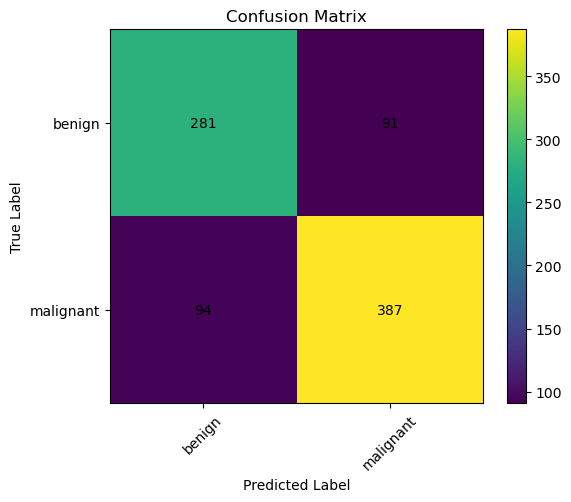

In [24]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

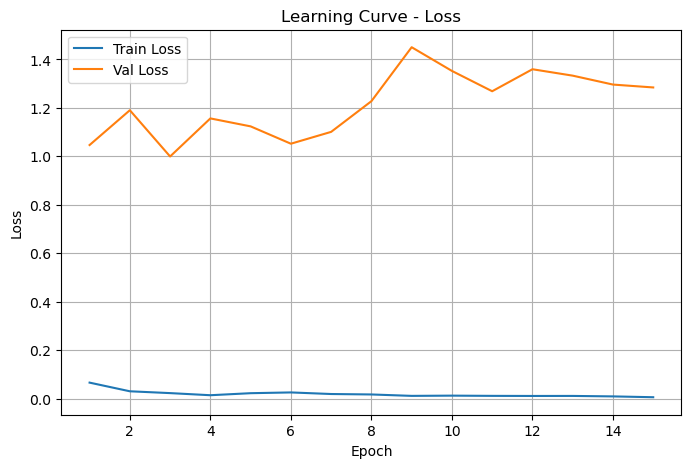

In [25]:
epochs_ran = range(1, len(history["epoch"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_loss"], label="Train Loss")
plt.plot(epochs_ran, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve - Loss")
plt.legend()
plt.grid(True)
plt.show()

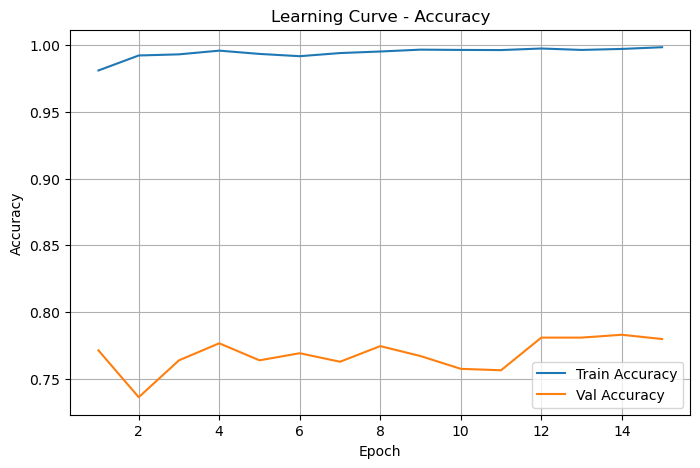

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_ran, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Accuracy")
plt.legend()
plt.grid(True)
plt.show()

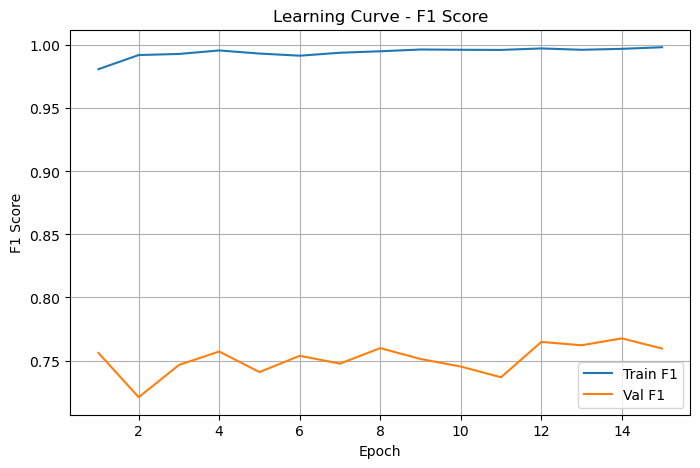

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_f1"], label="Train F1")
plt.plot(epochs_ran, history["val_f1"], label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Learning Curve - F1 Score")
plt.legend()
plt.grid(True)
plt.show()

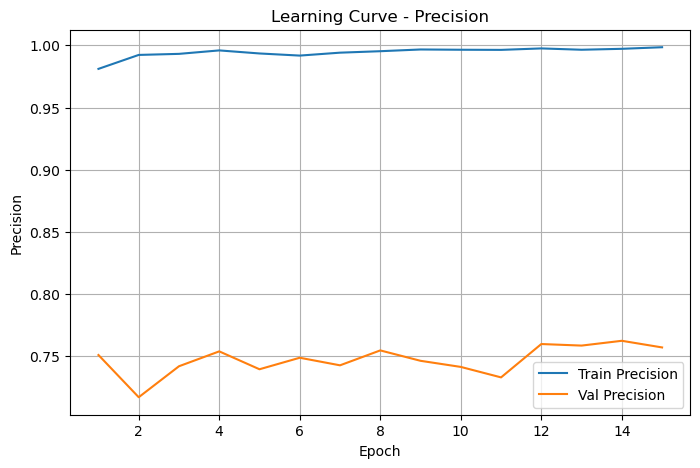

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_precision"], label="Train Precision")
plt.plot(epochs_ran, history["val_precision"], label="Val Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Learning Curve - Precision")
plt.legend()
plt.grid(True)
plt.show()

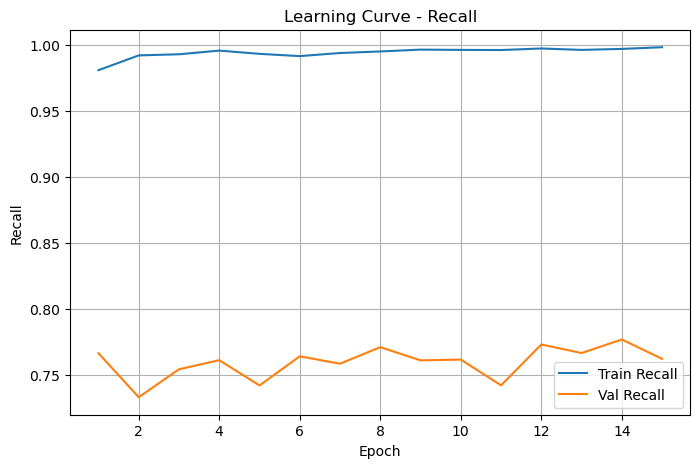

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_recall"], label="Train Recall")
plt.plot(epochs_ran, history["val_recall"], label="Val Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Learning Curve - Recall")
plt.legend()
plt.grid(True)
plt.show()

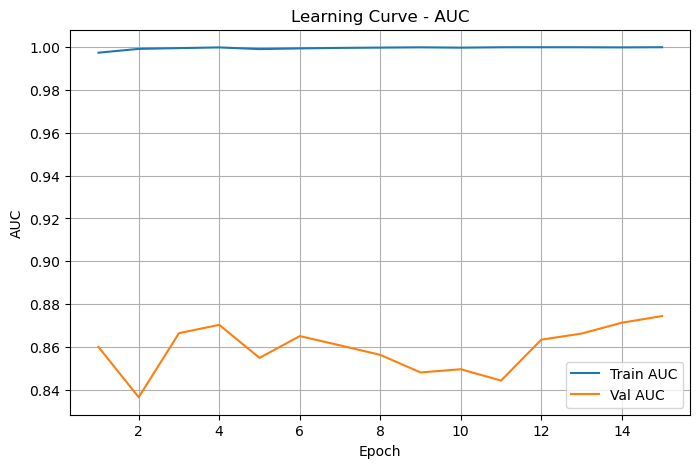

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history["train_auc"], label="Train AUC")
plt.plot(epochs_ran, history["val_auc"], label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Learning Curve - AUC")
plt.legend()
plt.grid(True)
plt.show()

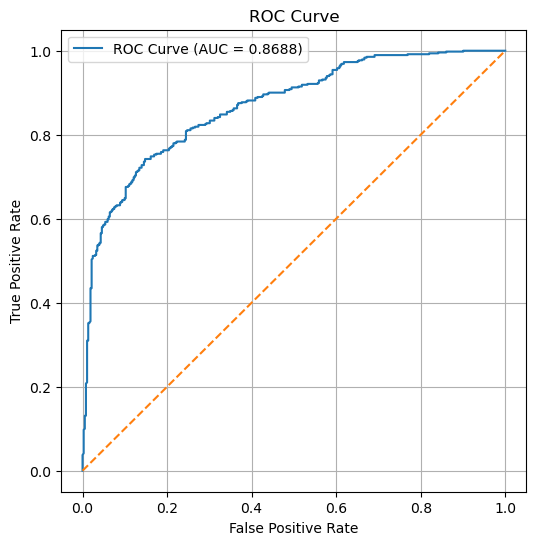

In [31]:
fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {test_metrics['auc']:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()